## X Gate Simulation with  Pulses

### Hamiltonian Implementation

The system Hamiltonian is based on the transmon qubit model with DRAG pulse shaping [Motzoi et al., PRL 103, 110501 (2009)]:

$
H(t)/\hbar = \Delta|2\rangle\langle 2| + \frac{\epsilon_x(t)}{2}(a + a^\dagger) + \frac{\epsilon_y(t)}{2}i(a^\dagger - a)
$

Where:
- $\Delta = \omega_{12} - \omega_{01}$ is the anharmonicity (-400 MHz in our simulation)
- $\epsilon_x(t)$ is the X-control field (Gaussian envelope)
- $\epsilon_y(t)$ is the Y-control field (DRAG correction)
- $a$/$a^\dagger$ are annihilation/creation operators

### Pulse Parameters
- **Pulse duration**: 6 ns (σ = 1.5 ns)

### Decoherence Model
Included collapse operators for:
- Energy relaxation (T₁ = 20 μs)
- Pure dephasing (T₂ = 10 μs)


[INFO] Calculating FAST DRAG coefficients for N = 4...
[INFO] Coefficients calculated in 0.98 seconds.

[INFO] Calibrating pulse amplitudes...

[INFO] Calibrating FAST DRAG pulse...


C:\Users\HP\anaconda3\lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


Optimal FAST DRAG amplitude A = 1.0000

[INFO] Calibrating HD DRAG pulse...
Optimal HD DRAG amplitude A = 0.5000

[INFO] Running simulations for all pulse types...

--- Running Simulation for: Gaussian Pulse ---
  Gate Time: 6.0 ns, Final State Populations:
    P(|0>): 2.6860%, P(|1>): 97.2346%, Leakage P(|2>): 0.0793%


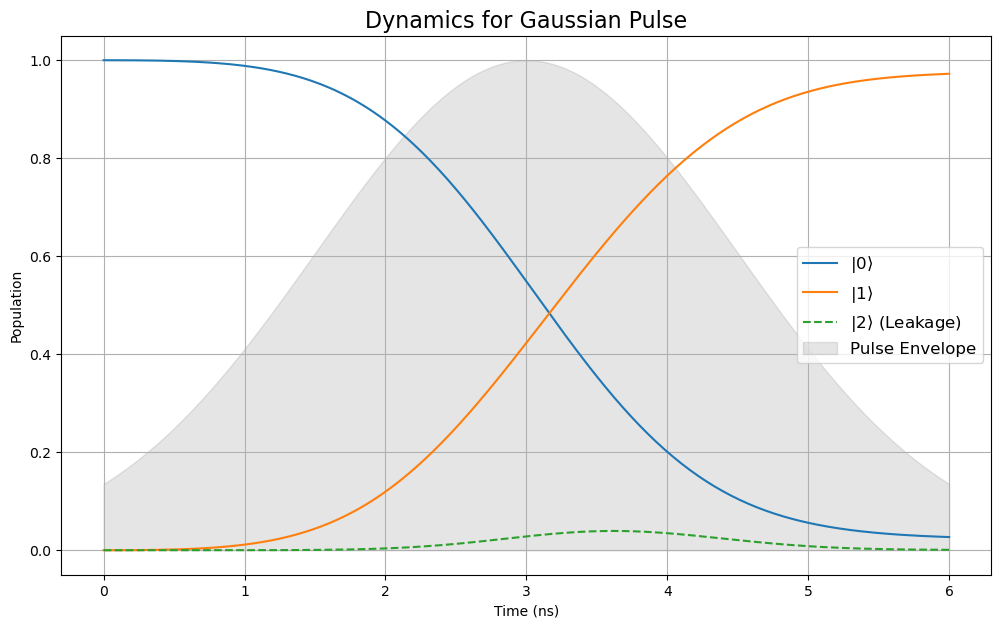

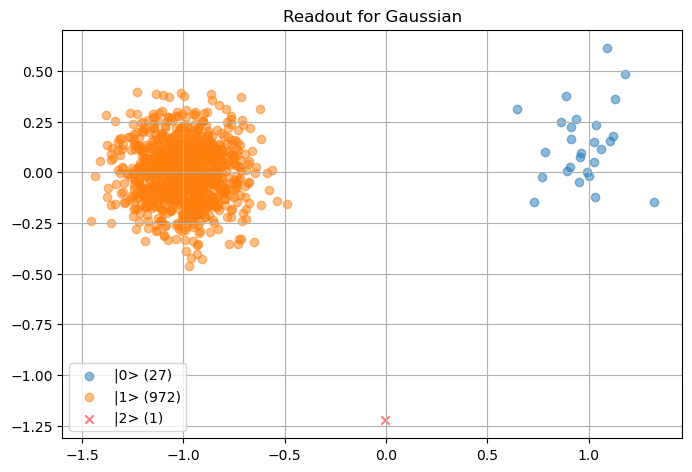


--- Running Simulation for: DRAG Pulse ---
  Gate Time: 6.0 ns, Final State Populations:
    P(|0>): 1.6214%, P(|1>): 98.3021%, Leakage P(|2>): 0.0766%


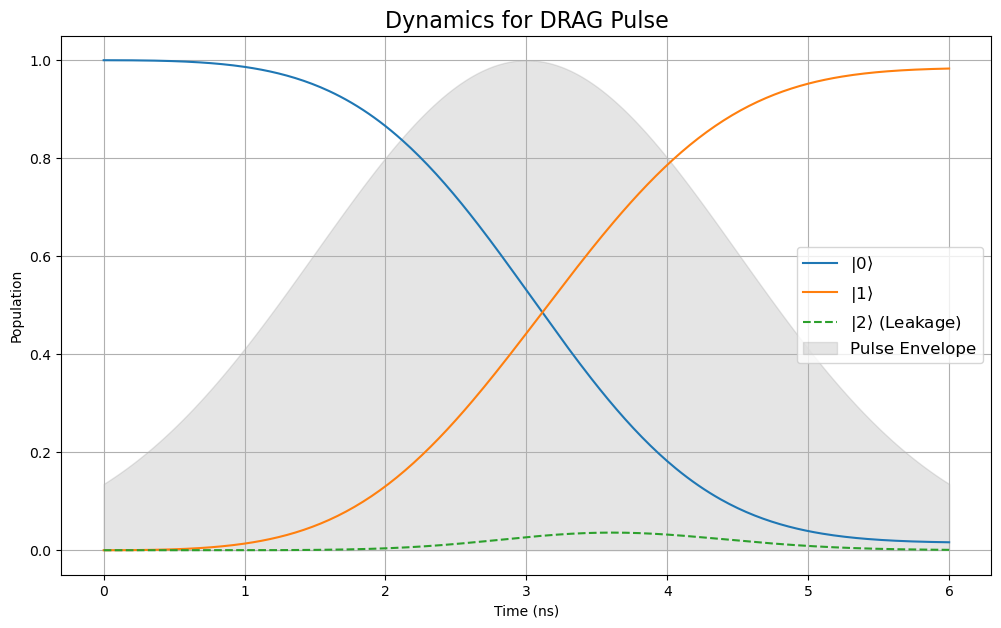

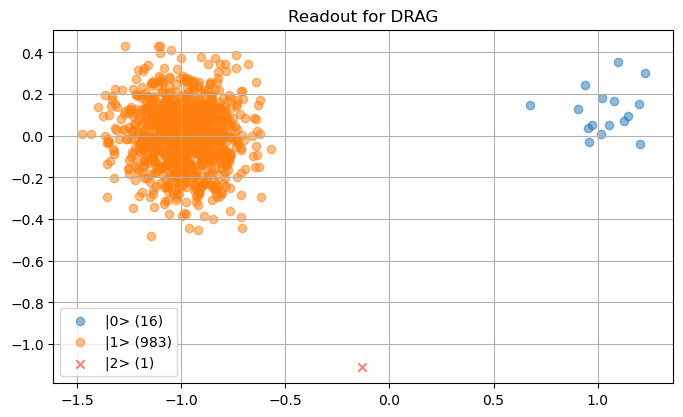


--- Running Simulation for: GRAPE-like Pulse ---
  Gate Time: 6.0 ns, Final State Populations:
    P(|0>): 1.5939%, P(|1>): 98.3324%, Leakage P(|2>): 0.0737%


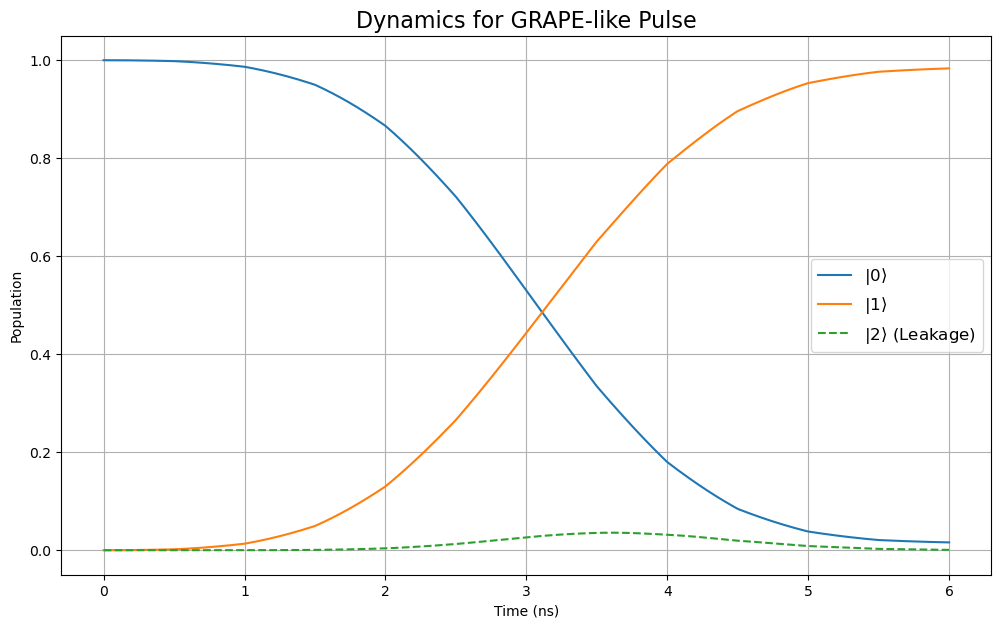

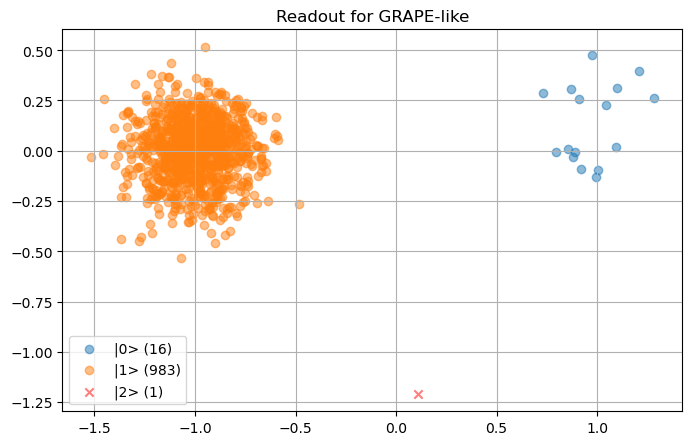


--- Running Simulation for: FAST DRAG Pulse ---
  Gate Time: 6.0 ns, Final State Populations:
    P(|0>): 3.4869%, P(|1>): 96.4873%, Leakage P(|2>): 0.0258%


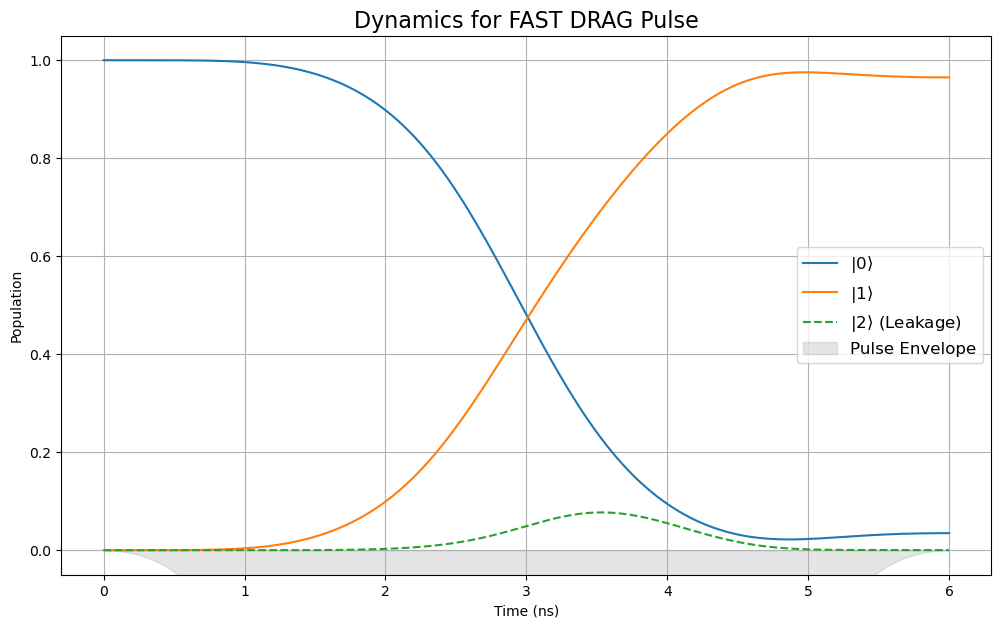

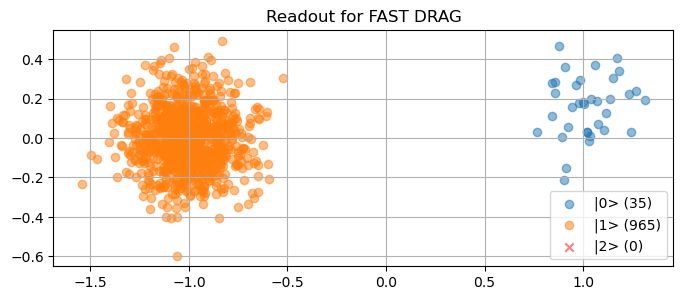


--- Running Simulation for: HD DRAG Pulse ---
  Gate Time: 6.0 ns, Final State Populations:
    P(|0>): 4.1133%, P(|1>): 95.8323%, Leakage P(|2>): 0.0544%


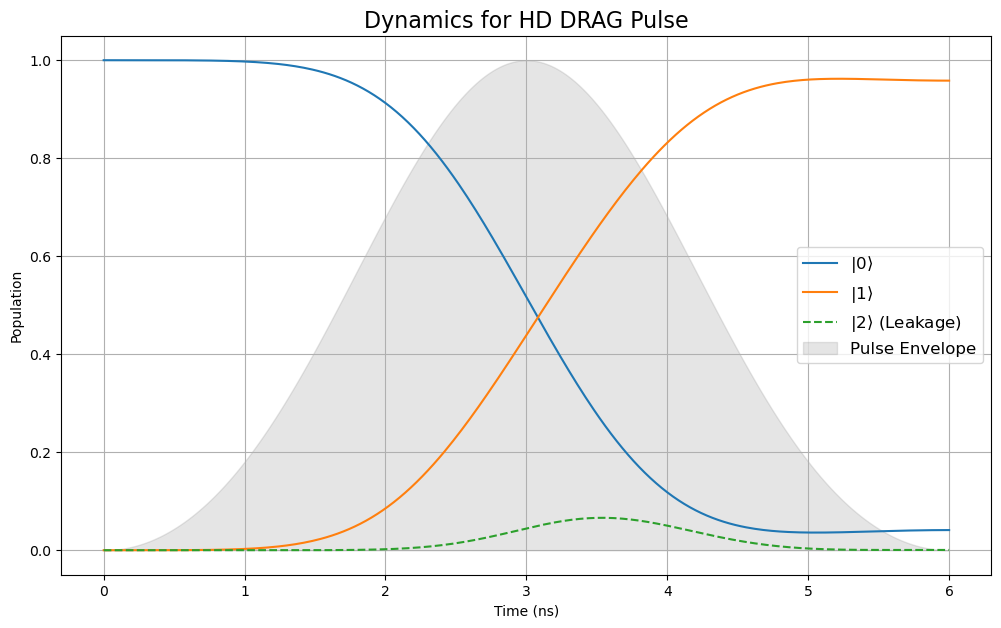

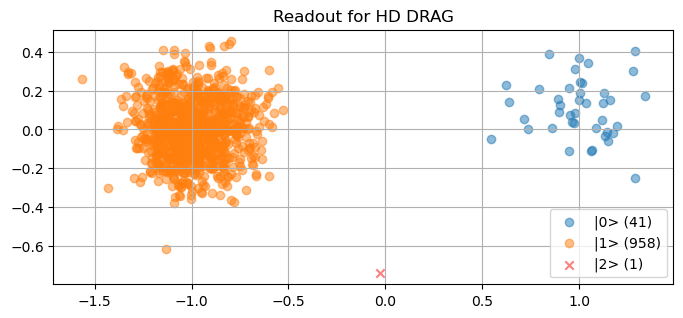


[INFO] Creating combined plot of all pulse shapes...


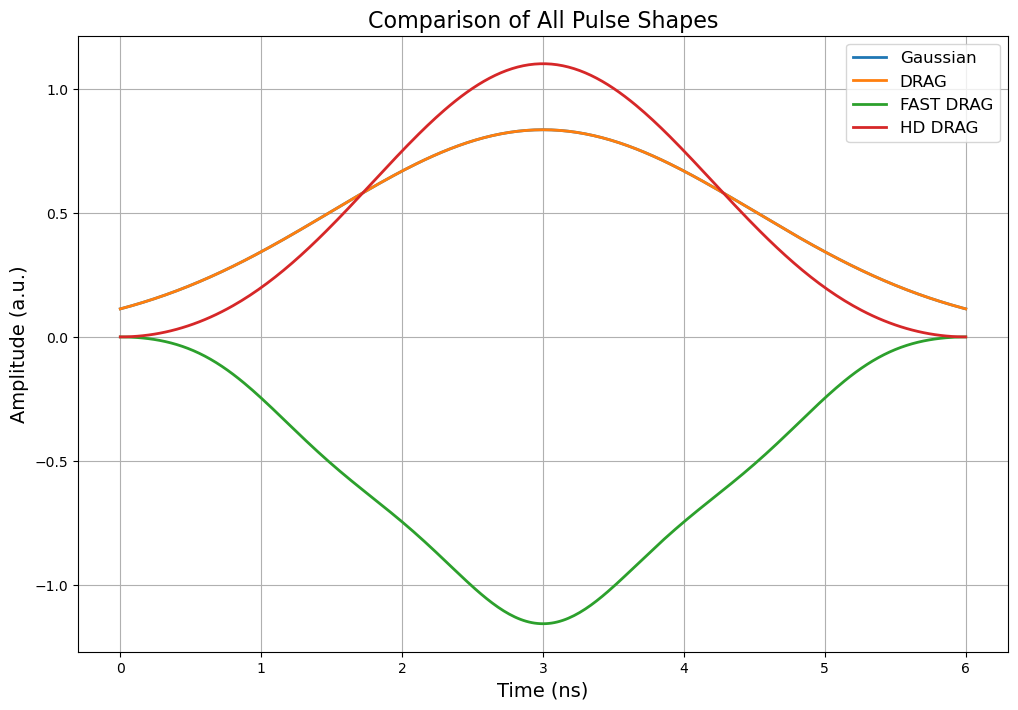

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, destroy, mesolve
from scipy.integrate import quad
from scipy.linalg import solve
import warnings
import time

# Suppress warnings
warnings.filterwarnings("ignore", category=np.ComplexWarning)

# ==============================================================================
# PULSE DEFINITION FUNCTIONS
# ==============================================================================

def calculate_fast_drag_coefficients(N_terms, t_p, anh_ghz, rot_angle):
    """Calculate coefficients for FAST DRAG pulse"""
    start_time = time.time()
    print(f"\n[INFO] Calculating FAST DRAG coefficients for N = {N_terms}...")
    
    def my_sinc(x): return np.sin(x)/x if x!=0 else 1.0
    def gn_hat(f,n,tp):
        t1 = tp*np.exp(-1j*np.pi*f*tp)*my_sinc(np.pi*f*tp)
        t2 = 0.5*tp*np.exp(-1j*np.pi*(f-n/tp)*tp)*my_sinc(np.pi*(f-n/tp)*tp)
        t3 = 0.5*tp*np.exp(-1j*np.pi*(f+n/tp)*tp)*my_sinc(np.pi*(f+n/tp)*tp)
        return t1-t2-t3
    
    abs_anh = np.abs(anh_ghz)
    f_ef_low, f_ef_high = abs_anh-0.05*abs_anh, abs_anh+0.05*abs_anh
    f_cutoff = 2*abs_anh
    intervals = [(f_ef_low,f_ef_high), (f_cutoff,f_cutoff+5)]
    weights = [5.0, 1.0]
    
    A_matrix = np.zeros((N_terms,N_terms), dtype=complex)
    for n in range(1,N_terms+1):
        for m in range(1,N_terms+1):
            integral_val = 0
            for w,(f_low,f_high) in zip(weights,intervals):
                integrand = lambda f: w*gn_hat(f,n,t_p)*np.conj(gn_hat(f,m,t_p))
                r,_ = quad(lambda f: np.real(integrand(f)), f_low, f_high, limit=100)
                i,_ = quad(lambda f: np.imag(integrand(f)), f_low, f_high, limit=100)
                integral_val += (r + 1j*i)
            A_matrix[n-1,m-1] = integral_val
    
    M = np.zeros((N_terms+1,N_terms+1))
    M[:N_terms,:N_terms] = 2*np.real(A_matrix)
    b = -np.ones(N_terms)
    M[:N_terms,N_terms] = b
    M[N_terms,:N_terms] = b.T
    rhs = np.zeros(N_terms+1)
    rhs[N_terms] = rot_angle/t_p
    c_coeffs = solve(M,rhs)[:N_terms]
    
    print(f"[INFO] Coefficients calculated in {time.time() - start_time:.2f} seconds.")
    return c_coeffs

def generate_readout_blobs(p0, p1, p2, label, num_shots=1000, noise_level=0.15):
    """Simulates an experimental IQ readout with the corrected NumPy broadcasting."""
    total_prob = p0 + p1 + p2
    if not np.isclose(total_prob, 1.0):
        p0, p1, p2 = p0/total_prob, p1/total_prob, p2/total_prob
    
    center_0, center_1, center_2 = np.array([1.0, 0.1]), np.array([-1.0, 0.0]), np.array([0.0, -1.0])
    n0 = int(np.round(p0*num_shots))
    n1 = int(np.round(p1*num_shots))
    n2 = num_shots - n0 - n1
    
    # Generate data using the robust method to avoid shape mismatch
    blob_0 = center_0[:, np.newaxis] + np.random.randn(2, n0) * noise_level
    blob_1 = center_1[:, np.newaxis] + np.random.randn(2, n1) * noise_level
    blob_2 = center_2[:, np.newaxis] + np.random.randn(2, n2) * noise_level
    
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*blob_0, alpha=0.5, label=f'|0> ({n0})')
    ax.scatter(*blob_1, alpha=0.5, label=f'|1> ({n1})')
    ax.scatter(*blob_2, alpha=0.5, label=f'|2> ({n2})', c='r', marker='x')
    ax.set_title(f"Readout for {label}"); ax.grid(True); ax.legend(); ax.set_aspect('equal'); plt.show()

def plot_population_dynamics(tlist, p0, p1, p2, label, pulse_env_norm):
    fig,ax = plt.subplots(1,1,figsize=(12,7))
    ax.plot(tlist,p0,label=r'$|0\rangle$')
    ax.plot(tlist,p1,label=r'$|1\rangle$')
    ax.plot(tlist,p2,label=r'$|2\rangle$ (Leakage)',ls='--')
    if pulse_env_norm: 
        ax.fill_between(tlist,0,pulse_env_norm,color='gray',alpha=0.2,label='Pulse Envelope')
    ax.set_title(f"Dynamics for {label} Pulse",fontsize=16)
    ax.set_xlabel("Time (ns)"); ax.set_ylabel("Population")
    ax.grid(True); ax.legend(fontsize=12); ax.set_ylim(-0.05,1.05)
    plt.show()

def run_combined_simulation():
    # ==========================================================================
    # 1. System and Pulse Parameters
    # ==========================================================================
    N = 3
    anh_ghz = -0.4
    anh_delta = anh_ghz * 2 * np.pi
    gate_time = 6.0
    pulse_sigma = gate_time/4.0
    pulse_center = gate_time/2.0
    tlist = np.linspace(0, gate_time, 301)
    required_area = np.pi
    pulse_amplitude = required_area/(pulse_sigma*np.sqrt(2*np.pi))

    # ==========================================================================
    # 2. Operators, Initial State, and Decoherence
    # ==========================================================================
    a = destroy(N)
    P0, P1, P2 = (basis(N,i)*basis(N,i).dag() for i in range(3))
    drive_op_x = a + a.dag()
    sigma_y01 = -1j*(basis(N,0)*basis(N,1).dag() - basis(N,1)*basis(N,0).dag())
    H0 = anh_delta * P2
    psi0 = basis(N,0)
    e_ops = [P0, P1, P2]
    T1 = 20000
    T2 = 10000
    gamma1 = 1/T1
    gamma_phi = 1/T2 - gamma1/2.0
    c_ops = [
        np.sqrt(gamma1)*destroy(N),
        np.sqrt(gamma_phi)*(P0-P1),
        np.sqrt(gamma_phi)*(P1-P2)
    ]

    # ==========================================================================
    # 3. Define ALL Pulse Envelopes
    # ==========================================================================
    # Common pulse arguments
    pulse_args = {
        'A': pulse_amplitude,
        't0': pulse_center,
        'sigma': pulse_sigma,
        'delta': anh_delta
    }

    # Gaussian pulse
    def gauss_env(t, args):
        return args['A'] * np.exp(-(t-args['t0'])**2/(2*args['sigma']**2))

    # DRAG pulse
    def drag_env(t, args):
        return -(1.0/args['delta']) * (-(t-args['t0'])/args['sigma']**2) * gauss_env(t, args)

    # GRAPE-like pulse (piecewise constant)
    pixel_width = 0.5
    num_pixels = int(gate_time/pixel_width)
    pixel_times = np.linspace(0, gate_time, num_pixels+1)
    ex_pixels = [gauss_env(t, pulse_args) for t in (pixel_times[:-1]+pixel_width/2)]
    ey_pixels = [drag_env(t, pulse_args) for t in (pixel_times[:-1]+pixel_width/2)]
    
    def grape_ex_env(t, args):
        return ex_pixels[int(t/pixel_width)] if t < gate_time else 0.0
    
    def grape_ey_env(t, args):
        return ey_pixels[int(t/pixel_width)] if t < gate_time else 0.0

    # FAST DRAG pulse
    c_n_fast = calculate_fast_drag_coefficients(N_terms=4, t_p=gate_time, 
                                              anh_ghz=anh_ghz, rot_angle=required_area)
    
    def g_n(t, n, t_p):
        return 1 - np.cos(2*np.pi*n*t/t_p)
    
    def g_n_derivative(t, n, t_p):
        return (2*np.pi*n/t_p) * np.sin(2*np.pi*n*t/t_p)
    
    def fast_drag_I(t, args):
        if 0 <= t <= args['t_p']:
            return args['A'] * sum(c*g_n(t, n+1, args['t_p']) for n, c in enumerate(args['c_n']))
        return 0.0
    
    def fast_drag_Q(t, args):
        if 0 <= t <= args['t_p']:
            return -(args['beta']/args['delta']) * args['A'] * sum(
                c*g_n_derivative(t, n+1, args['t_p']) for n, c in enumerate(args['c_n']))
        return 0.0

    # HD DRAG pulse
    beta2 = 1.0 / (anh_delta**2)
    
    def g_hd(t, t_p):
        w = 2*np.pi/t_p
        return 1 - (4/3)*np.cos(w*t) + (1/3)*np.cos(2*w*t) if 0 <= t <= t_p else 0.0
    
    def g_p(t, t_p):
        w = 2*np.pi/t_p
        return (4/3)*w*np.sin(w*t) - (2/3)*w*np.sin(2*w*t) if 0 <= t <= t_p else 0.0
    
    def g_pp(t, t_p):
        w = 2*np.pi/t_p
        return (4/3)*w**2*np.cos(w*t) - (4/3)*w**2*np.cos(2*w*t) if 0 <= t <= t_p else 0.0
    
    def g_ppp(t, t_p):
        w = 2*np.pi/t_p
        return -(4/3)*w**3*np.sin(w*t) + (8/3)*w**3*np.sin(2*w*t) if 0 <= t <= t_p else 0.0
    
    def omega_I_hd(t, args):
        return args['A'] * (g_hd(t, args['t_p']) + args['beta2'] * g_pp(t, args['t_p']))
    
    def omega_Q_hd(t, args):
        return -(args['beta']/args['delta']) * args['A'] * (
            g_p(t, args['t_p']) + args['beta2'] * g_ppp(t, args['t_p']))

    # ==========================================================================
    # 4. Calibrate Pulse Amplitudes
    # ==========================================================================
    print("\n[INFO] Calibrating pulse amplitudes...")
    
    # FAST DRAG calibration
    print("\n[INFO] Calibrating FAST DRAG pulse...")
    best_A_fast = 0
    max_pop1_fast = 0
    H_fast_calib = [H0, [drive_op_x/2, fast_drag_I], [sigma_y01/2, fast_drag_Q]]
    
    for A_test in np.linspace(0.5, 1.5, 21):
        args_test = {
            't_p': gate_time,
            'delta': anh_delta,
            'beta': 1.0,
            'c_n': c_n_fast,
            'A': A_test
        }
        res = mesolve(H_fast_calib, psi0, tlist, [], [P1], args=args_test)
        if res.expect[0][-1] > max_pop1_fast:
            max_pop1_fast = res.expect[0][-1]
            best_A_fast = A_test
    print(f"Optimal FAST DRAG amplitude A = {best_A_fast:.4f}")
    fast_drag_args = {
        't_p': gate_time,
        'delta': anh_delta,
        'beta': 1.0,
        'c_n': c_n_fast,
        'A': best_A_fast
    }

    # HD DRAG calibration
    print("\n[INFO] Calibrating HD DRAG pulse...")
    best_A_hd = 0
    max_pop1_hd = 0
    H_hd_calib = [H0, [drive_op_x/2, omega_I_hd], [sigma_y01/2, omega_Q_hd]]
    
    for A_test in np.linspace(0.1, 0.5, 41):
        args_test = {
            't_p': gate_time,
            'delta': anh_delta,
            'beta': 1.0,
            'beta2': beta2,
            'A': A_test
        }
        res = mesolve(H_hd_calib, psi0, tlist, [], [P1], args=args_test)
        if res.expect[0][-1] > max_pop1_hd:
            max_pop1_hd = res.expect[0][-1]
            best_A_hd = A_test
    print(f"Optimal HD DRAG amplitude A = {best_A_hd:.4f}")
    hd_drag_args = {
        't_p': gate_time,
        'delta': anh_delta,
        'beta': 1.0,
        'beta2': beta2,
        'A': best_A_hd
    }

    # ==========================================================================
    # 5. Define All FIVE Simulations
    # ==========================================================================
    simulations = [
        {
            'label': 'Gaussian',
            'H': [H0, [drive_op_x/2, gauss_env]],
            'args': pulse_args,
            'pulse_func': gauss_env
        },
        {
            'label': 'DRAG',
            'H': [H0, [drive_op_x/2, gauss_env], [sigma_y01/2, drag_env]],
            'args': pulse_args,
            'pulse_func': gauss_env
        },
        {
            'label': 'GRAPE-like',
            'H': [H0, [drive_op_x/2, grape_ex_env], [sigma_y01/2, grape_ey_env]],
            'args': {},
            'pulse_func': None
        },
        {
            'label': 'FAST DRAG',
            'H': H_fast_calib,
            'args': fast_drag_args,
            'pulse_func': fast_drag_I
        },
        {
            'label': 'HD DRAG',
            'H': H_hd_calib,
            'args': hd_drag_args,
            'pulse_func': omega_I_hd
        }
    ]

    # ==========================================================================
    # 6. Run Simulations and Display Results
    # ==========================================================================
    print("\n[INFO] Running simulations for all pulse types...")
    
    for sim in simulations:
        label = sim['label']
        print(f"\n--- Running Simulation for: {label} Pulse ---")
        
        # Run the simulation
        result = mesolve(sim['H'], psi0, tlist, c_ops, e_ops, args=sim['args'])
        pop0, pop1, pop2 = result.expect
        
        # Print results
        print(f"  Gate Time: {gate_time:.1f} ns, Final State Populations:")
        print(f"    P(|0>): {pop0[-1]:.4%}, P(|1>): {pop1[-1]:.4%}, Leakage P(|2>): {pop2[-1]:.4%}")
        
        # Prepare pulse envelope for plotting
        pulse_env_norm = None
        if sim['pulse_func']:
            env = [sim['pulse_func'](t, sim['args']) for t in tlist]
            max_env = max(np.abs(env)) or 1
            pulse_env_norm = [v/max_env for v in env]
        
        # Plot results
        plot_population_dynamics(tlist, pop0, pop1, pop2, label, pulse_env_norm)
        generate_readout_blobs(pop0[-1], pop1[-1], pop2[-1], label)

    # ==========================================================================
    # 7. Combined Plot of All Pulses
    # ==========================================================================
    print("\n[INFO] Creating combined plot of all pulse shapes...")
    
    plt.figure(figsize=(12, 8))
    
    # Plot each pulse shape
    for sim in simulations:
        if sim['pulse_func']:
            if sim['label'] == 'GRAPE-like':
                # Special handling for piecewise GRAPE pulse
                times = np.linspace(0, gate_time, 1000)
                values = [sim['pulse_func'](t, sim['args']) for t in times]
                plt.plot(times, values, label=sim['label'], lw=2)
            else:
                values = [sim['pulse_func'](t, sim['args']) for t in tlist]
                plt.plot(tlist, values, label=sim['label'], lw=2)
    
    plt.title("Comparison of All Pulse Shapes", fontsize=16)
    plt.xlabel("Time (ns)", fontsize=14)
    plt.ylabel("Amplitude (a.u.)", fontsize=14)
    plt.grid(True)
    plt.legend(fontsize=12)
    plt.show()

if __name__ == '__main__':
    run_combined_simulation()

HAMILTONIAN USED IN ALL SIMULATIONS (H/ħ)
Implementing an X-gate with two sequential π/2-pulses
H(t) = Δ⋅|2><2| + (Ex(t)/2)⋅(a+a†) + (Ey(t)/2)⋅(σy₀₁)


--- Running Simulation for: Gaussian Two-Pulse X-Gate ---
  Total Gate Time: 60.0 ns
  Final Population Percentages:
    P(|0>): 0.8962%
    P(|1>): 99.0995%
    P(|2>): 0.0043%  <-- Leakage


C:\Users\HP\anaconda3\lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


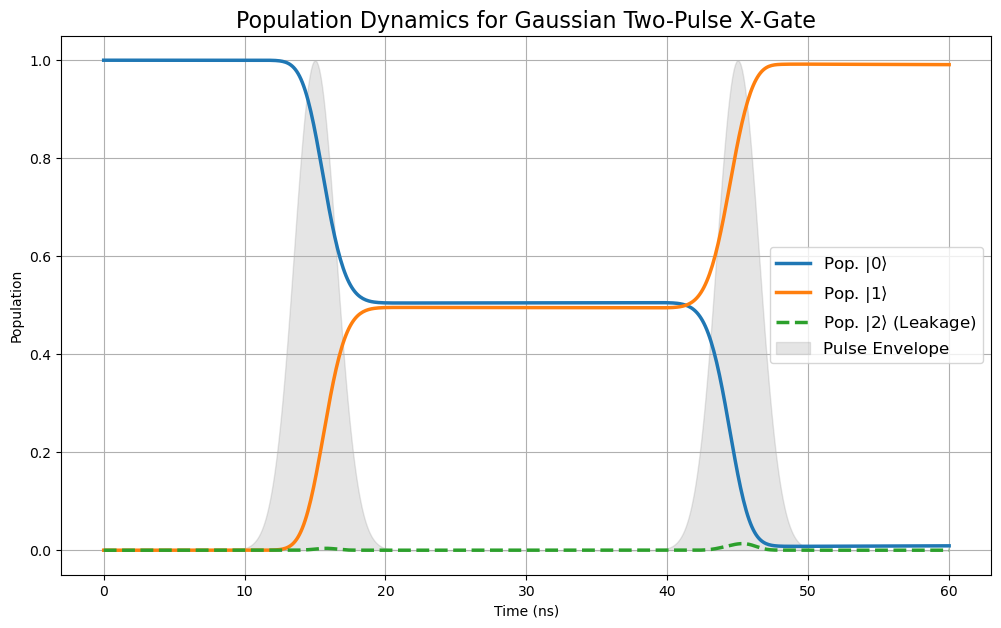

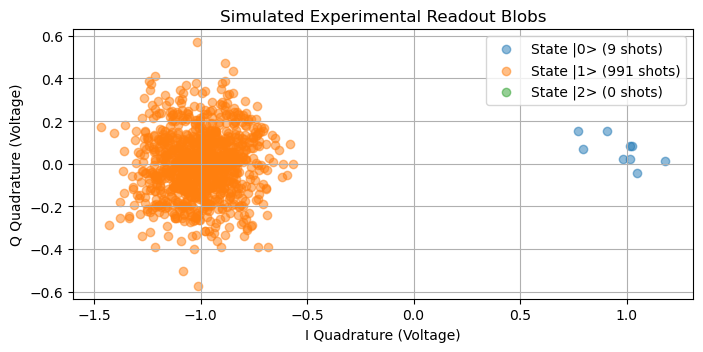


--- Running Simulation for: DRAG Two-Pulse X-Gate ---
  Total Gate Time: 60.0 ns
  Final Population Percentages:
    P(|0>): 0.8506%
    P(|1>): 99.1470%
    P(|2>): 0.0023%  <-- Leakage


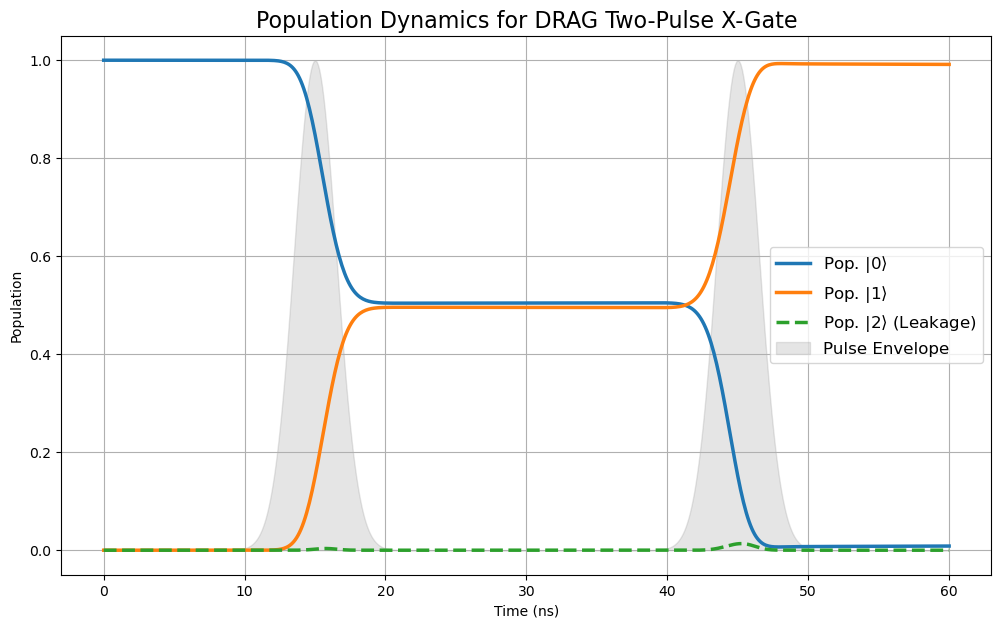

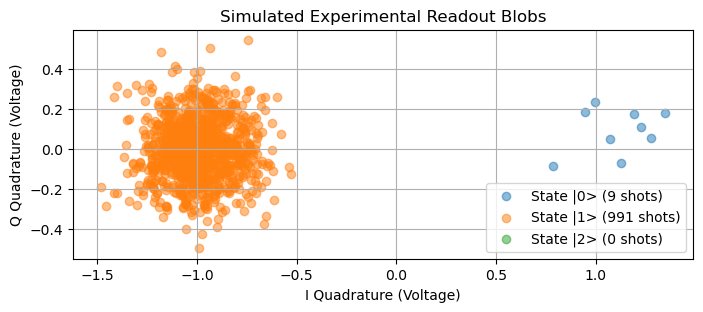


--- Running Simulation for: GRAPE-like Two-Pulse X-Gate ---
  Total Gate Time: 60.0 ns
  Final Population Percentages:
    P(|0>): 0.8623%
    P(|1>): 99.1355%
    P(|2>): 0.0022%  <-- Leakage


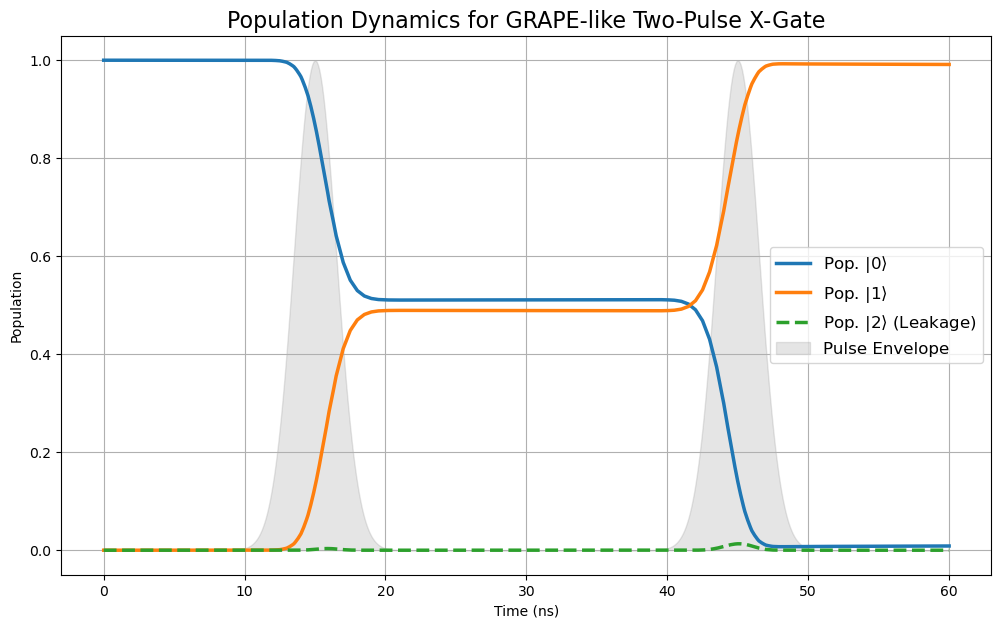

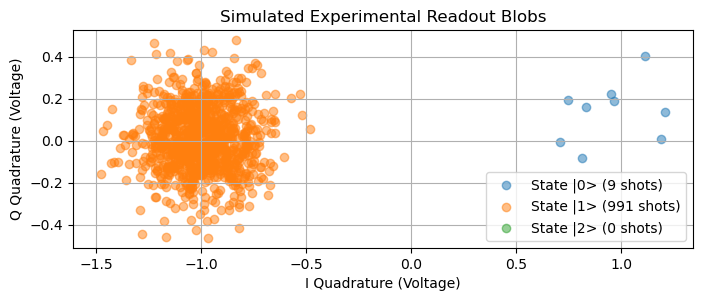

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    basis, destroy, mesolve
)

# ==============================================================================
# EXPERIMENTAL READOUT PLOT FUNCTION (UNCHANGED)
# ==============================================================================
def generate_readout_blobs(p0_final, p1_final, p2_final, num_shots=1000, noise_level=0.15):
    """
    Simulates an experimental IQ readout for a three-level system by generating
    noisy data points based on the final probabilities.
    """
    total_prob = p0_final + p1_final + p2_final
    if not np.isclose(total_prob, 1.0):
        p0_final /= total_prob
        p1_final /= total_prob
        p2_final /= total_prob

    center_0 = np.array([1.0, 0.1])
    center_1 = np.array([-1.0, 0.0])
    center_2 = np.array([0.0, -1.0])

    num_shots_0 = int(np.round(p0_final * num_shots))
    num_shots_1 = int(np.round(p1_final * num_shots))
    num_shots_2 = num_shots - num_shots_0 - num_shots_1

    blob_0_I = np.random.normal(loc=center_0[0], scale=noise_level, size=num_shots_0)
    blob_0_Q = np.random.normal(loc=center_0[1], scale=noise_level, size=num_shots_0)
    blob_1_I = np.random.normal(loc=center_1[0], scale=noise_level, size=num_shots_1)
    blob_1_Q = np.random.normal(loc=center_1[1], scale=noise_level, size=num_shots_1)
    blob_2_I = np.random.normal(loc=center_2[0], scale=noise_level, size=num_shots_2)
    blob_2_Q = np.random.normal(loc=center_2[1], scale=noise_level, size=num_shots_2)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(blob_0_I, blob_0_Q, alpha=0.5, label=f'State |0> ({num_shots_0} shots)')
    ax.scatter(blob_1_I, blob_1_Q, alpha=0.5, label=f'State |1> ({num_shots_1} shots)')
    ax.scatter(blob_2_I, blob_2_Q, alpha=0.5, label=f'State |2> ({num_shots_2} shots)')
    ax.set_title("Simulated Experimental Readout Blobs")
    ax.set_xlabel("I Quadrature (Voltage)"), ax.set_ylabel("Q Quadrature (Voltage)")
    ax.grid(True), ax.legend(), ax.set_aspect('equal', adjustable='box')
    plt.show()

# ==============================================================================
# HELPER FUNCTION FOR PLOTTING POPULATIONS (UNCHANGED)
# ==============================================================================
def plot_population_dynamics(tlist, pop0, pop1, pop2, label, pulse_env_norm):
    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    ax.plot(tlist, pop0, label=r'Pop. $|0\rangle$', lw=2.5)
    ax.plot(tlist, pop1, label=r'Pop. $|1\rangle$', lw=2.5)
    ax.plot(tlist, pop2, label=r'Pop. $|2\rangle$ (Leakage)', lw=2.5, linestyle='--')
    ax.fill_between(tlist, 0, pulse_env_norm, color='gray', alpha=0.2, label='Pulse Envelope')
    ax.set_title(f"Population Dynamics for {label} Two-Pulse X-Gate", fontsize=16)
    ax.set_xlabel("Time (ns)"), ax.set_ylabel("Population")
    ax.grid(True), ax.legend(fontsize=12), ax.set_ylim(-0.05, 1.05)
    plt.show()

# ==============================================================================
# MAIN SIMULATION FUNCTION (MODIFIED FOR TWO PULSES)
# ==============================================================================
def run_full_two_pulse_comparison():
    # --- 1. Print the Hamiltonian Being Used ---
    print("="*70)
    print("HAMILTONIAN USED IN ALL SIMULATIONS (H/ħ)")
    print("Implementing an X-gate with two sequential π/2-pulses")
    print("="*70)
    print("H(t) = Δ⋅|2><2| + (Ex(t)/2)⋅(a+a†) + (Ey(t)/2)⋅(σy₀₁)")
    print("="*70 + "\n")

    # --- 2. System and Pulse Parameters ---
    N = 3
    anharmonicity_ghz = -0.4
    anharmonicity_delta = anharmonicity_ghz * 2 * np.pi
    
    # Timing for two pulses
    total_time = 60.0
    pulse1_t0, pulse2_t0 = 15.0, 45.0
    pulse_duration = 6.0 # Make pulses a bit wider to fit in the time window
    pulse_sigma = pulse_duration / 4.0
    tlist = np.linspace(0, total_time, 601)

    # Area for a single π/2 pulse. Angle = ∫(Amp/2)dt = π/4 => ∫Amp dt = π/2
    required_area = np.pi / 2.0
    pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))

    # --- 3. Operators and Initial State ---
    a = destroy(N)
    P0, P1, P2 = (basis(N, i) * basis(N, i).dag() for i in range(3))
    drive_op_x = a + a.dag()
    sigma_y01 = -1j * (basis(N, 0) * basis(N, 1).dag() - basis(N, 1) * basis(N, 0).dag())
    H0 = anharmonicity_delta * P2
    psi0 = basis(N, 0)
    e_ops = [P0, P1, P2]
    
    # --- 3.5. Collapse Operators (Added) ---
    # Typical values for superconducting qubits (T1 ~ 20-100μs, T2 ~ 10-50μs)
    T1 = 20.0  # in microseconds
    T2 = 10.0  # in microseconds
    
    # Convert to nanoseconds (since our simulation is in ns)
    T1_ns = T1 * 1000
    T2_ns = T2 * 1000
    
    # Calculate decay rates
    gamma1 = 1 / T1_ns  # Energy relaxation rate
    gamma_phi = (1 / T2_ns) - (1 / (2 * T1_ns))  # Pure dephasing rate
    
    # Collapse operators
    c_ops = []
    # Energy relaxation |1> -> |0>
    c_ops.append(np.sqrt(gamma1) * destroy(N))
    # Energy relaxation |2> -> |1>
    c_ops.append(np.sqrt(gamma1) * destroy(N))
    # Pure dephasing |0><1| and |1><2|
    c_ops.append(np.sqrt(gamma_phi) * (P0 - P1))
    c_ops.append(np.sqrt(gamma_phi) * (P1 - P2))

    # --- 4. Two-Pulse Envelope Definitions ---
    pulse_args = {
        'A': pulse_amplitude, 't0_1': pulse1_t0, 't0_2': pulse2_t0,
        'sigma': pulse_sigma, 'delta': anharmonicity_delta
    }
    
    def two_pulse_gauss_env(t, args):
        p1 = args['A'] * np.exp(-(t - args['t0_1'])**2 / (2 * args['sigma']**2))
        p2 = args['A'] * np.exp(-(t - args['t0_2'])**2 / (2 * args['sigma']**2))
        return p1 + p2

    def two_pulse_drag_env(t, args):
        gauss1 = args['A'] * np.exp(-(t - args['t0_1'])**2 / (2 * args['sigma']**2))
        deriv1 = -(t - args['t0_1']) / (args['sigma']**2) * gauss1
        
        gauss2 = args['A'] * np.exp(-(t - args['t0_2'])**2 / (2 * args['sigma']**2))
        deriv2 = -(t - args['t0_2']) / (args['sigma']**2) * gauss2
        
        return -(1.0 / args['delta']) * (deriv1 + deriv2)

    # --- 5. Define All Three Simulations ---
    # Case 1: Standard Gaussian
    H_gauss = [H0, [drive_op_x / 2, two_pulse_gauss_env]]
    # Case 2: Ideal DRAG
    H_drag = [H0, [drive_op_x / 2, two_pulse_gauss_env], [sigma_y01 / 2, two_pulse_drag_env]]
    # Case 3: GRAPE-like (Pixelated DRAG)
    pixel_width = 0.5
    num_pixels = int(total_time / pixel_width)
    ex_pixels = [two_pulse_gauss_env(t, pulse_args) for t in np.linspace(0, total_time, num_pixels)]
    ey_pixels = [two_pulse_drag_env(t, pulse_args) for t in np.linspace(0, total_time, num_pixels)]
    def grape_ex_env(t, args):
        if t >= total_time: return 0.0
        return ex_pixels[int(t / pixel_width)]
    def grape_ey_env(t, args):
        if t >= total_time: return 0.0
        return ey_pixels[int(t / pixel_width)]
    H_grape = [H0, [drive_op_x / 2, grape_ex_env], [sigma_y01 / 2, grape_ey_env]]

    simulations = [
        {'label': 'Gaussian', 'H': H_gauss, 'args': pulse_args},
        {'label': 'DRAG', 'H': H_drag, 'args': pulse_args},
        {'label': 'GRAPE-like', 'H': H_grape, 'args': {}},
    ]

    # --- 6. Run Simulations and Display Results ---
    pulse_envelope_normalized = [two_pulse_gauss_env(t, pulse_args) / pulse_amplitude for t in tlist]

    for sim in simulations:
        label = sim['label']
        print(f"\n--- Running Simulation for: {label} Two-Pulse X-Gate ---")

        result = mesolve(sim['H'], psi0, tlist, c_ops, e_ops, args=sim['args'])
        pop0, pop1, pop2 = result.expect

        print(f"  Total Gate Time: {total_time:.1f} ns")
        print("  Final Population Percentages:")
        print(f"    P(|0>): {pop0[-1]*100:.4f}%")
        print(f"    P(|1>): {pop1[-1]*100:.4f}%")
        print(f"    P(|2>): {pop2[-1]*100:.4f}%  <-- Leakage")

        # Display the plots for this simulation
        plot_population_dynamics(tlist, pop0, pop1, pop2, label, pulse_envelope_normalized)
        generate_readout_blobs(pop0[-1], pop1[-1], pop2[-1])


if __name__ == '__main__':
    run_full_two_pulse_comparison()

HAMILTONIAN USED IN ALL SIMULATIONS (H/ħ)
Implementing an X-gate with three sequential pulses
H(t) = Δ⋅|2><2| + (Ex(t)/2)⋅(a+a†) + (Ey(t)/2)⋅(σy₀₁)


--- Running Simulation for: Gaussian Three-Pulse X-Gate ---
Pulse sequence: π/3 (15ns) → π/3 (45ns) → π/3 (75ns)
  Total Gate Time: 90.0 ns
  Final Population Percentages:
    P(|0>): 0.9236%
    P(|1>): 99.0738%
    P(|2>): 0.0026%  <-- Leakage


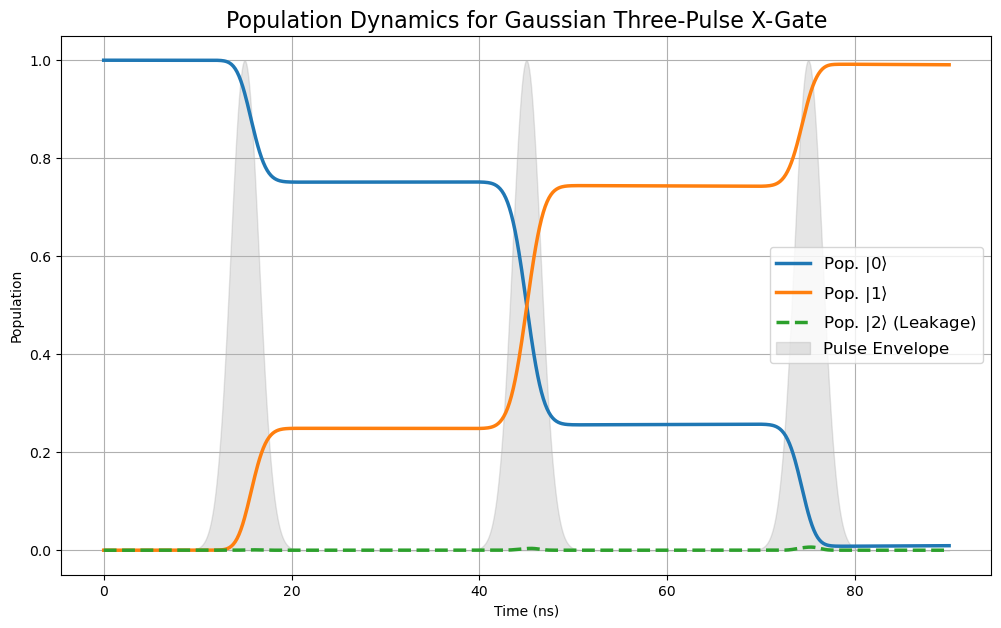

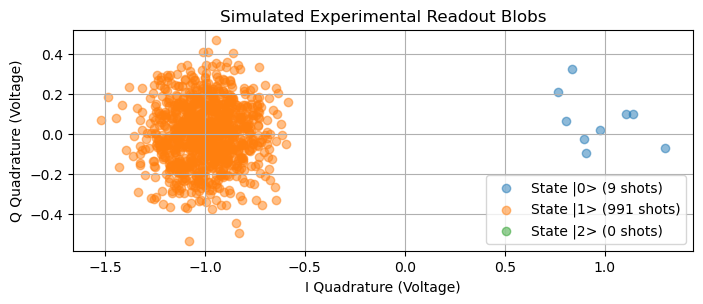


--- Running Simulation for: DRAG Three-Pulse X-Gate ---
Pulse sequence: π/3 (15ns) → π/3 (45ns) → π/3 (75ns)
  Total Gate Time: 90.0 ns
  Final Population Percentages:
    P(|0>): 0.9013%
    P(|1>): 99.0971%
    P(|2>): 0.0016%  <-- Leakage


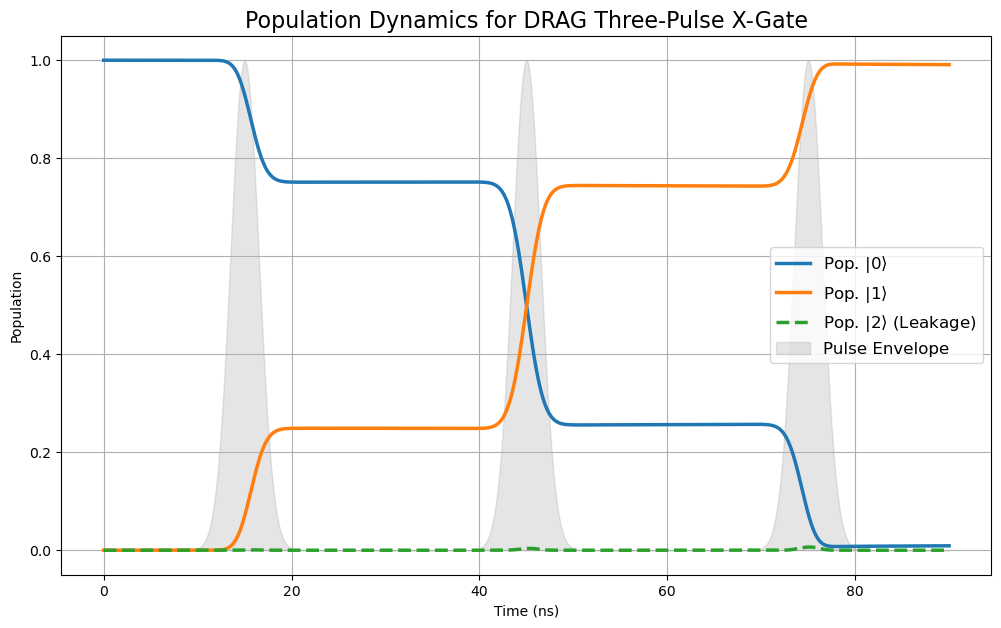

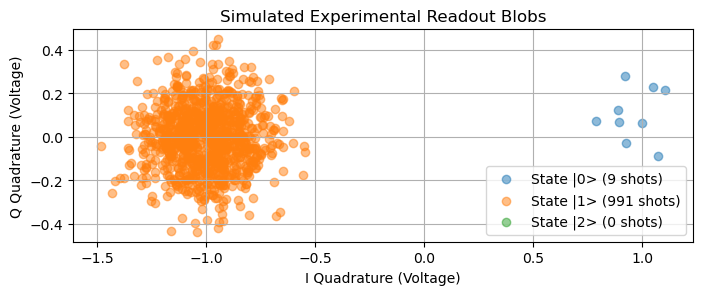


--- Running Simulation for: GRAPE-like Three-Pulse X-Gate ---
Pulse sequence: π/3 (15ns) → π/3 (45ns) → π/3 (75ns)
  Total Gate Time: 90.0 ns
  Final Population Percentages:
    P(|0>): 0.9087%
    P(|1>): 99.0899%
    P(|2>): 0.0014%  <-- Leakage


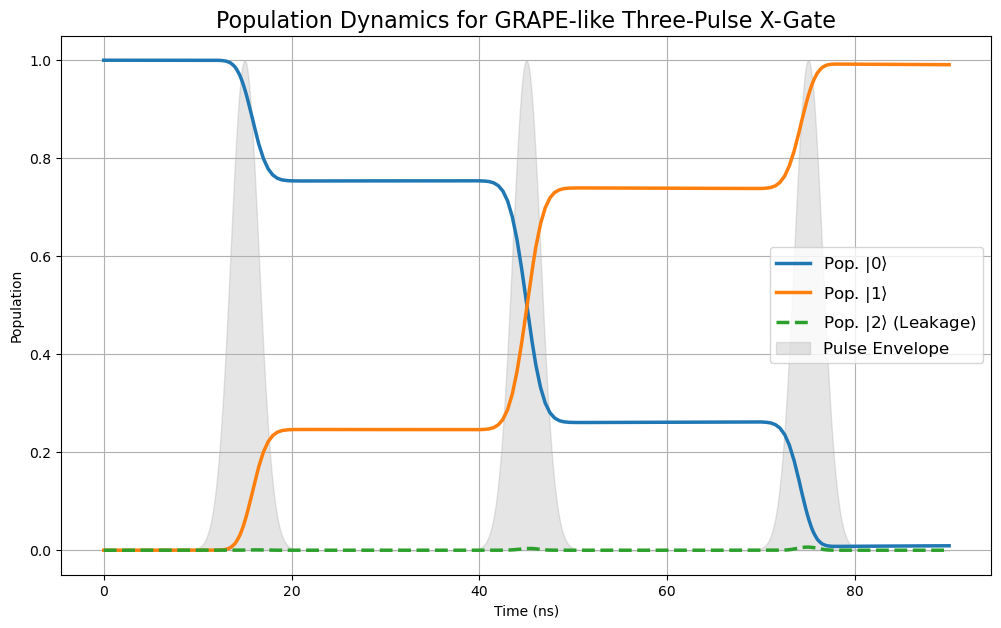

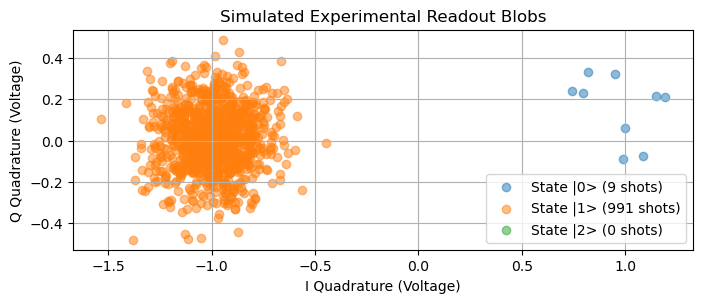

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    basis, destroy, mesolve
)

# ==============================================================================
# EXPERIMENTAL READOUT PLOT FUNCTION (UNCHANGED)
# ==============================================================================
def generate_readout_blobs(p0_final, p1_final, p2_final, num_shots=1000, noise_level=0.15):
    """
    Simulates an experimental IQ readout for a three-level system by generating
    noisy data points based on the final probabilities.
    """
    total_prob = p0_final + p1_final + p2_final
    if not np.isclose(total_prob, 1.0):
        p0_final /= total_prob
        p1_final /= total_prob
        p2_final /= total_prob

    center_0 = np.array([1.0, 0.1])
    center_1 = np.array([-1.0, 0.0])
    center_2 = np.array([0.0, -1.0])

    num_shots_0 = int(np.round(p0_final * num_shots))
    num_shots_1 = int(np.round(p1_final * num_shots))
    num_shots_2 = num_shots - num_shots_0 - num_shots_1

    blob_0_I = np.random.normal(loc=center_0[0], scale=noise_level, size=num_shots_0)
    blob_0_Q = np.random.normal(loc=center_0[1], scale=noise_level, size=num_shots_0)
    blob_1_I = np.random.normal(loc=center_1[0], scale=noise_level, size=num_shots_1)
    blob_1_Q = np.random.normal(loc=center_1[1], scale=noise_level, size=num_shots_1)
    blob_2_I = np.random.normal(loc=center_2[0], scale=noise_level, size=num_shots_2)
    blob_2_Q = np.random.normal(loc=center_2[1], scale=noise_level, size=num_shots_2)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(blob_0_I, blob_0_Q, alpha=0.5, label=f'State |0> ({num_shots_0} shots)')
    ax.scatter(blob_1_I, blob_1_Q, alpha=0.5, label=f'State |1> ({num_shots_1} shots)')
    ax.scatter(blob_2_I, blob_2_Q, alpha=0.5, label=f'State |2> ({num_shots_2} shots)')
    ax.set_title("Simulated Experimental Readout Blobs")
    ax.set_xlabel("I Quadrature (Voltage)"), ax.set_ylabel("Q Quadrature (Voltage)")
    ax.grid(True), ax.legend(), ax.set_aspect('equal', adjustable='box')
    plt.show()

# ==============================================================================
# HELPER FUNCTION FOR PLOTTING POPULATIONS (UNCHANGED)
# ==============================================================================
def plot_population_dynamics(tlist, pop0, pop1, pop2, label, pulse_env_norm):
    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    ax.plot(tlist, pop0, label=r'Pop. $|0\rangle$', lw=2.5)
    ax.plot(tlist, pop1, label=r'Pop. $|1\rangle$', lw=2.5)
    ax.plot(tlist, pop2, label=r'Pop. $|2\rangle$ (Leakage)', lw=2.5, linestyle='--')
    ax.fill_between(tlist, 0, pulse_env_norm, color='gray', alpha=0.2, label='Pulse Envelope')
    ax.set_title(f"Population Dynamics for {label} Three-Pulse X-Gate", fontsize=16)
    ax.set_xlabel("Time (ns)"), ax.set_ylabel("Population")
    ax.grid(True), ax.legend(fontsize=12), ax.set_ylim(-0.05, 1.05)
    plt.show()

# ==============================================================================
# MAIN SIMULATION FUNCTION (MODIFIED FOR THREE PULSES)
# ==============================================================================
def run_full_three_pulse_comparison():
    # --- 1. Print the Hamiltonian Being Used ---
    print("="*70)
    print("HAMILTONIAN USED IN ALL SIMULATIONS (H/ħ)")
    print("Implementing an X-gate with three sequential pulses")
    print("="*70)
    print("H(t) = Δ⋅|2><2| + (Ex(t)/2)⋅(a+a†) + (Ey(t)/2)⋅(σy₀₁)")
    print("="*70 + "\n")

    # --- 2. System and Pulse Parameters ---
    N = 3
    anharmonicity_ghz = -0.4
    anharmonicity_delta = anharmonicity_ghz * 2 * np.pi
    
    # Timing for three pulses (π/3, π/3, π/3)
    total_time = 90.0
    pulse1_t0, pulse2_t0, pulse3_t0 = 15.0, 45.0, 75.0
    pulse_duration = 6.0
    pulse_sigma = pulse_duration / 4.0
    tlist = np.linspace(0, total_time, 901)

    # Area for each π/3 pulse (total rotation = π)
    required_area = np.pi / 3.0
    pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))

    # --- 3. Operators and Initial State ---
    a = destroy(N)
    P0, P1, P2 = (basis(N, i) * basis(N, i).dag() for i in range(3))
    drive_op_x = a + a.dag()
    sigma_y01 = -1j * (basis(N, 0) * basis(N, 1).dag() - basis(N, 1) * basis(N, 0).dag())
    H0 = anharmonicity_delta * P2
    psi0 = basis(N, 0)
    e_ops = [P0, P1, P2]
    
    # --- 3.5. Collapse Operators ---
    # Typical values for superconducting qubits (T1 ~ 20-100μs, T2 ~ 10-50μs)
    T1 = 20.0  # in microseconds
    T2 = 10.0  # in microseconds
    
    # Convert to nanoseconds (since our simulation is in ns)
    T1_ns = T1 * 1000
    T2_ns = T2 * 1000
    
    # Calculate decay rates
    gamma1 = 1 / T1_ns  # Energy relaxation rate
    gamma_phi = (1 / T2_ns) - (1 / (2 * T1_ns))  # Pure dephasing rate
    
    # Collapse operators
    c_ops = []
    # Energy relaxation |1> -> |0>
    c_ops.append(np.sqrt(gamma1) * destroy(N))
    # Energy relaxation |2> -> |1>
    c_ops.append(np.sqrt(gamma1) * destroy(N))
    # Pure dephasing |0><1| and |1><2|
    c_ops.append(np.sqrt(gamma_phi) * (P0 - P1))
    c_ops.append(np.sqrt(gamma_phi) * (P1 - P2))

    # --- 4. Three-Pulse Envelope Definitions ---
    pulse_args = {
        'A': pulse_amplitude, 
        't0_1': pulse1_t0, 't0_2': pulse2_t0, 't0_3': pulse3_t0,
        'sigma': pulse_sigma, 'delta': anharmonicity_delta
    }
    
    def three_pulse_gauss_env(t, args):
        p1 = args['A'] * np.exp(-(t - args['t0_1'])**2 / (2 * args['sigma']**2))
        p2 = args['A'] * np.exp(-(t - args['t0_2'])**2 / (2 * args['sigma']**2))
        p3 = args['A'] * np.exp(-(t - args['t0_3'])**2 / (2 * args['sigma']**2))
        return p1 + p2 + p3

    def three_pulse_drag_env(t, args):
        gauss1 = args['A'] * np.exp(-(t - args['t0_1'])**2 / (2 * args['sigma']**2))
        deriv1 = -(t - args['t0_1']) / (args['sigma']**2) * gauss1
        
        gauss2 = args['A'] * np.exp(-(t - args['t0_2'])**2 / (2 * args['sigma']**2))
        deriv2 = -(t - args['t0_2']) / (args['sigma']**2) * gauss2
        
        gauss3 = args['A'] * np.exp(-(t - args['t0_3'])**2 / (2 * args['sigma']**2))
        deriv3 = -(t - args['t0_3']) / (args['sigma']**2) * gauss3
        
        return -(1.0 / args['delta']) * (deriv1 + deriv2 + deriv3)

    # --- 5. Define All Three Simulations ---
    # Case 1: Standard Gaussian
    H_gauss = [H0, [drive_op_x / 2, three_pulse_gauss_env]]
    # Case 2: Ideal DRAG
    H_drag = [H0, [drive_op_x / 2, three_pulse_gauss_env], [sigma_y01 / 2, three_pulse_drag_env]]
    # Case 3: GRAPE-like (Pixelated DRAG)
    pixel_width = 0.5
    num_pixels = int(total_time / pixel_width)
    ex_pixels = [three_pulse_gauss_env(t, pulse_args) for t in np.linspace(0, total_time, num_pixels)]
    ey_pixels = [three_pulse_drag_env(t, pulse_args) for t in np.linspace(0, total_time, num_pixels)]
    def grape_ex_env(t, args):
        if t >= total_time: return 0.0
        return ex_pixels[int(t / pixel_width)]
    def grape_ey_env(t, args):
        if t >= total_time: return 0.0
        return ey_pixels[int(t / pixel_width)]
    H_grape = [H0, [drive_op_x / 2, grape_ex_env], [sigma_y01 / 2, grape_ey_env]]

    simulations = [
        {'label': 'Gaussian', 'H': H_gauss, 'args': pulse_args},
        {'label': 'DRAG', 'H': H_drag, 'args': pulse_args},
        {'label': 'GRAPE-like', 'H': H_grape, 'args': {}},
    ]

    # --- 6. Run Simulations and Display Results ---
    pulse_envelope_normalized = [three_pulse_gauss_env(t, pulse_args) / pulse_amplitude for t in tlist]

    for sim in simulations:
        label = sim['label']
        print(f"\n--- Running Simulation for: {label} Three-Pulse X-Gate ---")
        print("Pulse sequence: π/3 (15ns) → π/3 (45ns) → π/3 (75ns)")

        result = mesolve(sim['H'], psi0, tlist, c_ops, e_ops, args=sim['args'])
        pop0, pop1, pop2 = result.expect

        print(f"  Total Gate Time: {total_time:.1f} ns")
        print("  Final Population Percentages:")
        print(f"    P(|0>): {pop0[-1]*100:.4f}%")
        print(f"    P(|1>): {pop1[-1]*100:.4f}%")
        print(f"    P(|2>): {pop2[-1]*100:.4f}%  <-- Leakage")

        # Display the plots for this simulation
        plot_population_dynamics(tlist, pop0, pop1, pop2, label, pulse_envelope_normalized)
        generate_readout_blobs(pop0[-1], pop1[-1], pop2[-1])


if __name__ == '__main__':
    run_full_three_pulse_comparison()